In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as  plt


In [2]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
 #Fix Zero Values That Are Invalid Values
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

In [6]:
df.isna().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

About 49% of the Insulin values are missing, which is a significant portion of the data. This could potentially impact the performance of our model if we choose to impute these values.

In [7]:
df = df.drop('Insulin', axis=1)


In [8]:
# Fill missing values with median
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
df[cols] = df[cols].fillna(df[cols].median())


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
68,1,95.0,66.0,13.0,19.6,0.334,25,0
734,2,105.0,75.0,29.0,23.3,0.560,53,0
20,3,126.0,88.0,41.0,39.3,0.704,27,0
715,7,187.0,50.0,33.0,33.9,0.826,34,1
724,1,111.0,94.0,29.0,32.8,0.265,45,0


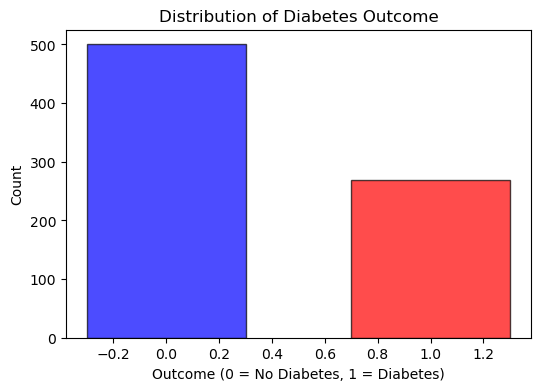

In [11]:
output = df['Outcome'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(output.index, output.values, color=['blue', 'red'], alpha=0.7, edgecolor='black', width=0.6)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()

In [12]:
df.groupby('Outcome').mean()


,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,35.383582,0.550500,37.067164


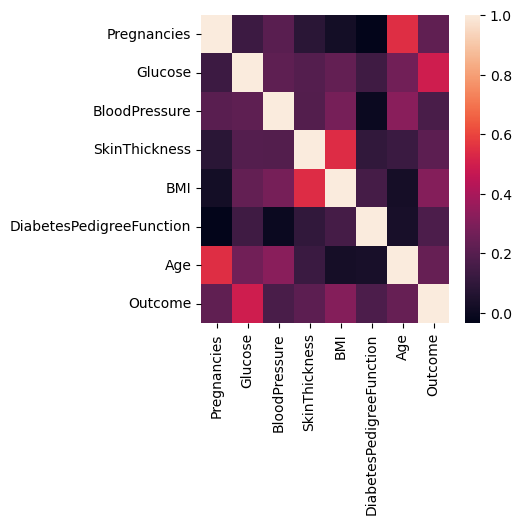

In [13]:
plt.figure(figsize=(4,4))
sns.heatmap(df.corr())
plt.show()

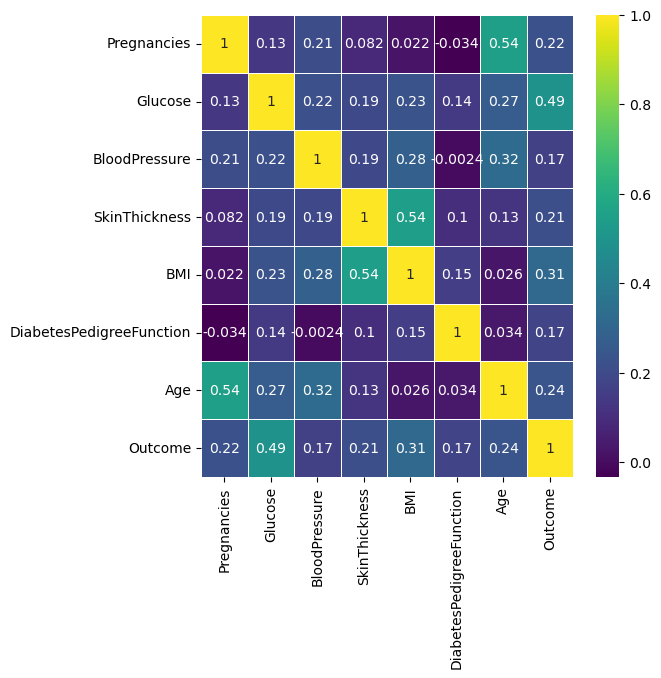

In [14]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(), annot=True, cmap='viridis', linewidths=0.5)
plt.show()

In [15]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [18]:
print(x_train.shape)
print(x_test.shape)

(614, 7)
(154, 7)


In [19]:
x_train
# x_train is pandas dataframe

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,72.0,29.0,32.3,0.304,21
618,9,112.0,82.0,24.0,28.2,1.282,50
346,1,139.0,46.0,19.0,28.7,0.654,22
294,0,161.0,50.0,29.0,21.9,0.254,65
231,6,134.0,80.0,37.0,46.2,0.238,46
...,...,...,...,...,...,...,...
71,5,139.0,64.0,35.0,28.6,0.411,26
106,1,96.0,122.0,29.0,22.4,0.207,27
270,10,101.0,86.0,37.0,45.6,1.136,38
435,0,141.0,72.0,29.0,42.4,0.205,29


In [20]:
scaler = StandardScaler()
scaler.fit(x_train)


,copy,True
,with_mean,True
,with_std,True


In [21]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
x_train_scaled
x_test_scaled
# we can see that both are numpy array but we need to convert them into data frame 

array([[ 0.68185612, -0.79146606, -1.1770325 , ...,  0.23786472,
        -0.11637247,  0.87809089],
       [-0.52639686, -0.32605067,  0.22915558, ...,  0.4831796 ,
        -0.954231  , -1.03594038],
       [-0.52639686, -0.45902649, -0.68073083, ..., -0.22390447,
        -0.9245197 , -1.03594038],
       ...,
       [ 1.28598261, -0.89119794, -0.01899526, ...,  0.64191276,
         0.04703966,  2.0961108 ],
       [-0.52639686,  0.80424387, -0.18442915, ..., -0.62795252,
        -0.39268751, -0.33992901],
       [ 1.28598261, -1.58932103, -0.18442915, ...,  0.42545845,
         0.70068816,  0.53008521]])

In [23]:
x_train_scaled=pd.DataFrame(x_train_scaled , columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [24]:
x_train_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
0,-0.526397,-1.256881,-0.018995,0.034298,-0.007450,-0.490735,-1.035940
1,1.588046,-0.326051,0.808174,-0.560583,-0.599092,2.415030,1.487101
2,-0.828460,0.571536,-2.169636,-1.155463,-0.526941,0.549161,-0.948939
3,-1.130523,1.302903,-1.838768,0.034298,-1.508200,-0.639291,2.792122
4,0.681856,0.405316,0.642740,0.986106,1.998360,-0.686829,1.139095
...,...,...,...,...,...,...,...
609,0.379793,0.571536,-0.680731,0.748154,-0.541371,-0.172824,-0.600933
610,-0.828460,-0.857954,4.116852,0.034298,-1.436049,-0.778934,-0.513932
611,1.890109,-0.691734,1.139042,0.986106,1.911778,1.981245,0.443084
612,-1.130523,0.638024,-0.018995,0.034298,1.450009,-0.784877,-0.339929


In [25]:
x_test_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
0,0.681856,-0.791466,-1.177033,0.510202,0.237865,-0.116372,0.878091
1,-0.526397,-0.326051,0.229156,0.391226,0.483180,-0.954231,-1.035940
2,-0.526397,-0.459026,-0.680731,0.034298,-0.223904,-0.924520,-1.035940
3,1.285983,-0.492270,0.642740,0.034298,-1.118582,1.149329,0.095078
4,0.983919,0.471804,1.469910,0.034298,-0.353777,-0.770021,1.487101
...,...,...,...,...,...,...,...
149,1.588046,1.435879,1.304476,0.034298,-0.281626,-0.496677,1.400099
150,-0.828460,-1.489589,-1.342466,0.153274,0.136853,2.322925,-0.774936
151,1.285983,-0.891198,-0.018995,0.034298,0.641913,0.047040,2.096111
152,-0.526397,0.804244,-0.184429,1.105082,-0.627953,-0.392688,-0.339929


In [26]:
np.round(x_train.describe(),1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
count,614.0,614.0,614.0,614.0,614.0,614.0,614.0
mean,3.7,121.8,72.2,28.7,32.4,0.5,32.9
std,3.3,30.1,12.1,8.4,6.9,0.3,11.5
min,0.0,44.0,24.0,8.0,18.2,0.1,21.0
25%,1.0,100.0,64.0,24.0,27.3,0.2,24.0
50%,3.0,117.0,72.0,29.0,32.0,0.4,29.0
75%,6.0,139.0,80.0,32.0,36.4,0.6,40.0
max,17.0,199.0,122.0,63.0,67.1,2.4,81.0


In [27]:
np.round(x_train_scaled.describe(),1).sample(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
mean,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0
75%,0.7,0.6,0.6,0.4,0.6,0.4,0.6


Effect of Scaling , Why scaling is important?

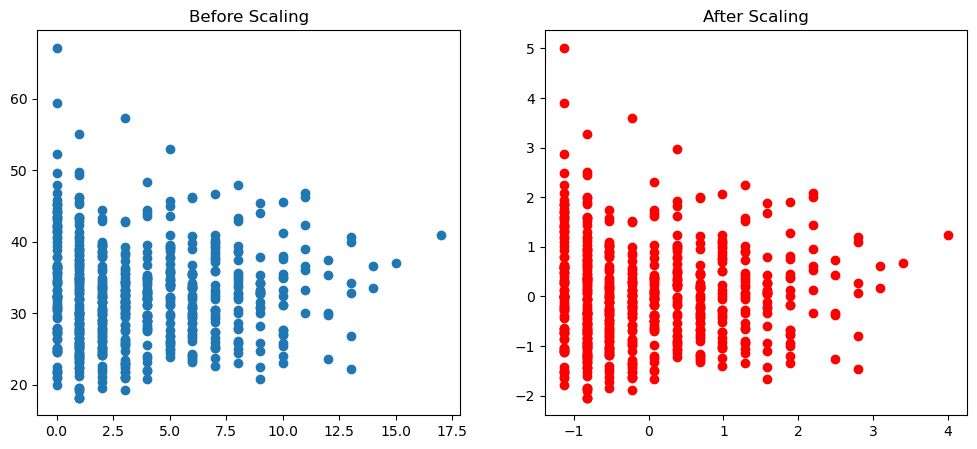

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Pregnancies'], x_train['BMI'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Pregnancies'], x_train_scaled['BMI'],color='red')
ax2.set_title("After Scaling")
plt.show()

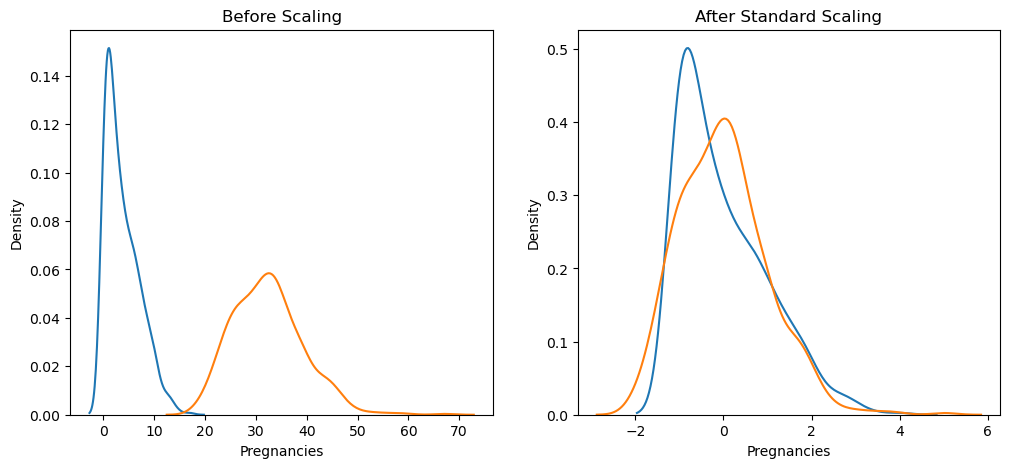

In [29]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Pregnancies'], ax=ax1)
sns.kdeplot(x_train['BMI'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Pregnancies'], ax=ax2)
sns.kdeplot(x_train_scaled['BMI'], ax=ax2)
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression


In [31]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()


In [32]:

lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.7467532467532467
Scaled 0.7467532467532467


In [35]:
from sklearn.neighbors import KNeighborsClassifier

In [36]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred=knn.predict(x_test_scaled)

In [38]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.6948051948051948
Scaled 0.7467532467532467


#support vector machine


In [42]:
print("classification_report:\n", classification_report(y_test, y_pred))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))

classification_report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76        99
           1       0.57      0.62      0.59        55

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.70       154

confusion_matrix:
 [[73 26]
 [21 34]]


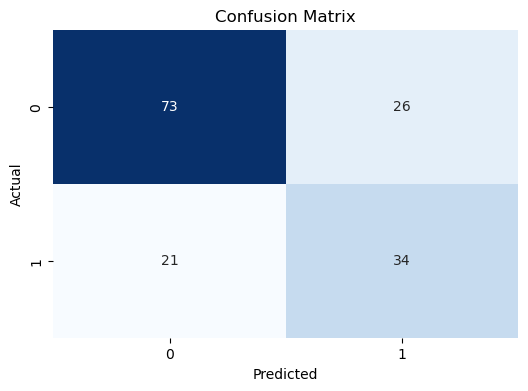

In [43]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
616,6,117.0,96.0,29.0,28.7,0.157,30,0
150,1,136.0,74.0,50.0,37.4,0.399,24,0
319,6,194.0,78.0,29.0,23.5,0.129,59,1
553,1,88.0,62.0,24.0,29.9,0.422,23,0
736,0,126.0,86.0,27.0,27.4,0.515,21,0


Using this as raw input we can predict the output 

In [48]:
input_data = np.array([6,194.0,78.0,29.0,23.5,0.129,59]).reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data)

prediction = knn.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[1]
The person is diabetic


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
